### QED-C Application-Oriented Benchmarks - Pre-defined Equal1-Runner

Using Qiskit to construct and run benchmarks, but inserting in Equal1 way of executing. 

## Default configurations
Change the following values to control benchmark parameters

In [13]:
# Generic becnhmark paramters
min_qubits = 2
max_qubits = 6
skip_qubits = 1
max_circuits = 6
num_shots = 1000

# Equal1 device specific
equal1_device = "equal1_simulator_cpu"
equal1_noise_model = "bell1-6-lin"

Setup equal1 execution environment

In [ ]:
import base64

from qbraid import QbraidProvider
from qiskit import QuantumCircuit, qasm2


class QBraidBackEnd():
    def __init__(self):
        self.name = "QBraidEqual1Backend"

class QBraidResult:
    def __init__(self, counts, exec_time, transpiled_circuit_metrics):
        self.exec_time = exec_time
        self.counts = counts
        self.transpiled_circuit_metrics = transpiled_circuit_metrics

    def get_counts(self, qc):
        return self.counts

    def get_transpiled_circuit_metrics(self):
        return self.transpiled_circuit_metrics

class QBraidExecutor():
    def __init__(self):
        provider = QbraidProvider()
        self.device = provider.get_device("equal1_simulator_cpu")

    def __call__(self, qc : QuantumCircuit, backend_name : str, backend, shots, **kwargs) -> QBraidResult:
        print(f"attempting to run {qc} on {backend_name}, on {backend} with {shots} and {kwargs}")

        job = self.device.run(qc, shots=shots, noise_model="bell1-6-lin")
        job.wait_for_final_state()  # Wait for the job to complete and get final state

        if job.status().name != "COMPLETED":
            # raise ValueError("job failed")
            assert f"\n@@@@@@@@@@@@@@ \n JOB FAILED for {qc} \n @@@@@@@@@@@@@@@@@@ \n "

        result = job.result()
        counts = result.data.get_counts()
        print(counts)

        result_json = job.client.get_job_results(job.id)
        inner_exec_time = result_json["inner_execution_time"]


        transpiled_circuit = base64.b64decode(result_json['compiledOutput']).decode('utf-8')
        transpiled_qc = qasm2.loads(transpiled_circuit, custom_instructions=qasm2.LEGACY_CUSTOM_INSTRUCTIONS)

        from _common.qiskit.execute import get_circuit_metrics
        metrics = get_circuit_metrics(transpiled_qc)


        return QBraidResult(counts, inner_exec_time, metrics)


In [20]:
# Common setup parameters
backend_id = "qasm_simulator"

hub = ""
group = ""
project = ""
provider_backend = None

exec_options = {
    "executor" : QBraidExecutor()
}


### Deutsch-Jozsa

Deutsch-Jozsa Benchmark Program - Qiskit
... execution starting at Jul 24, 2025 16:44:34 UTC
************
Executing [2] circuits with num_qubits = 3
attempting to run       ┌────────────┐               ░       ░ ┌────────────┐             ░ ┌─┐»
q8_0: ┤ U(π/2,0,π) ├───────────────░───────░─┤ U(π/2,0,π) ├─────────────░─┤M├»
      ├────────────┤               ░       ░ ├────────────┤             ░ └╥┘»
q8_1: ┤ U(π/2,0,π) ├───────────────░───────░─┤ U(π/2,0,π) ├─────────────░──╫─»
      └┬──────────┬┘┌────────────┐ ░ ┌───┐ ░ ├────────────┤┌──────────┐ ░  ║ »
q8_2: ─┤ U(π,0,π) ├─┤ U(π/2,0,π) ├─░─┤ X ├─░─┤ U(π/2,0,π) ├┤ U(π,0,π) ├─░──╫─»
       └──────────┘ └────────────┘ ░ └───┘ ░ └────────────┘└──────────┘ ░  ║ »
c8: 2/═════════════════════════════════════════════════════════════════════╩═»
                                                                           0 »
«         
«q8_0: ───
«      ┌─┐
«q8_1: ┤M├
«      └╥┘
«q8_2: ─╫─
«       ║ 
«c8: 2/═╩═
«       1  on qasm_simulator, on Q

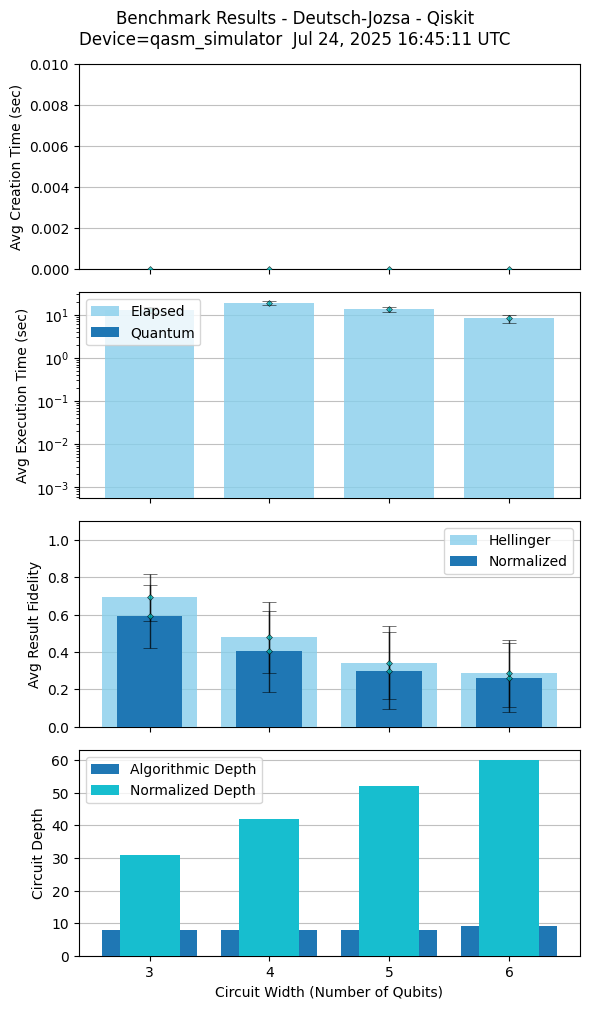

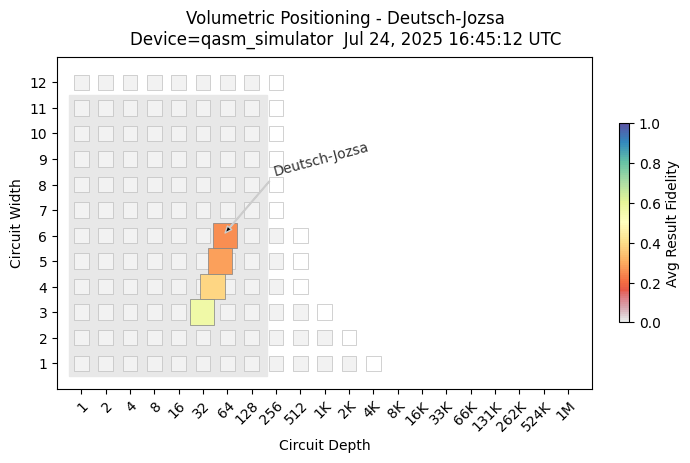

In [21]:
import sys
sys.path.insert(1, "deutsch-jozsa/qiskit")
import dj_benchmark
dj_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Bernstein-Vazirani - Method 1

Bernstein-Vazirani (1) Benchmark Program - Qiskit
... execution starting at Jul 24, 2025 16:45:34 UTC
************
Executing [4] circuits with num_qubits = 3
attempting to run        ┌────────────┐               ░  ░ ┌────────────┐             ░ ┌─┐   
q16_0: ┤ U(π/2,0,π) ├───────────────░──░─┤ U(π/2,0,π) ├─────────────░─┤M├───
       ├────────────┤               ░  ░ ├────────────┤             ░ └╥┘┌─┐
q16_1: ┤ U(π/2,0,π) ├───────────────░──░─┤ U(π/2,0,π) ├─────────────░──╫─┤M├
       └┬──────────┬┘┌────────────┐ ░  ░ ├────────────┤┌──────────┐ ░  ║ └╥┘
q16_2: ─┤ U(π,0,π) ├─┤ U(π/2,0,π) ├─░──░─┤ U(π/2,0,π) ├┤ U(π,0,π) ├─░──╫──╫─
        └──────────┘ └────────────┘ ░  ░ └────────────┘└──────────┘ ░  ║  ║ 
c16: 2/════════════════════════════════════════════════════════════════╩══╩═
                                                                       0  1  on qasm_simulator, on QasmSimulator('qasm_simulator') with 1000 and {}
{'00': 883, '01': 55, '10': 59, '11': 3}
attempting to run  

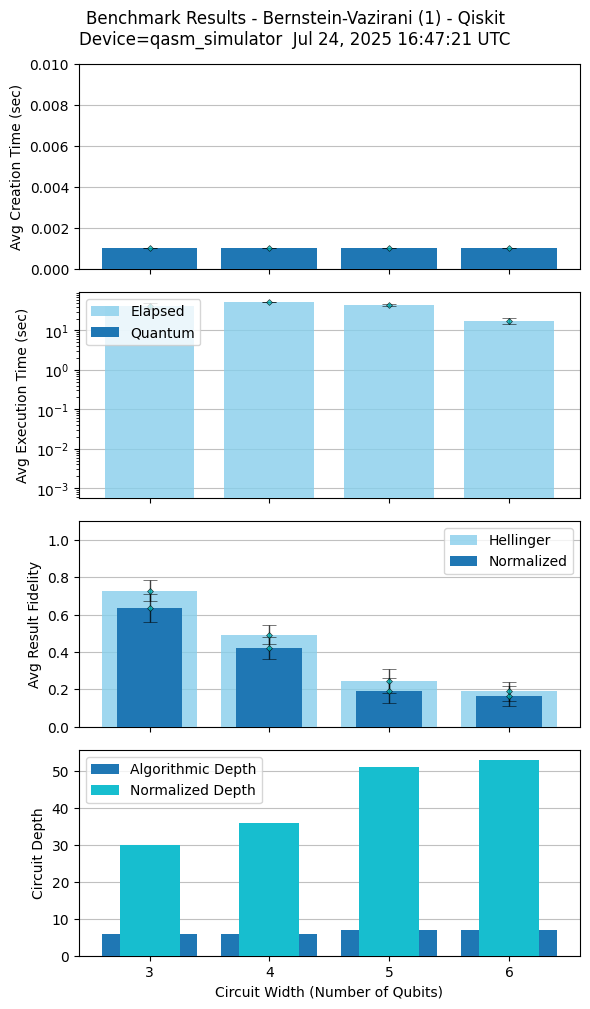

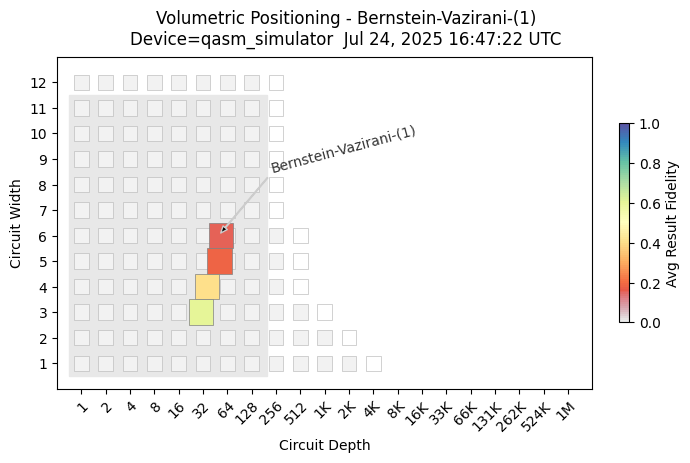

In [22]:
import sys
sys.path.insert(1, "bernstein-vazirani")
import bv_benchmark
bv_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Hidden Shift

Hidden Shift Benchmark Program - Qiskit
... execution starting at Jul 24, 2025 15:49:00 UTC
************
Executing [4] circuits with num_qubits = 2
************
Executing [6] circuits with num_qubits = 4
************
Executing [6] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 8, 0.204
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 16, 0.091, 2.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.001, 35.417, 0.0 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.786, 0.715

************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 8, 0.204
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 17, 0.088, 4.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.001, 43.102, 0.0 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.429, 0.391

************
Average Circuit Algorithmic Dep

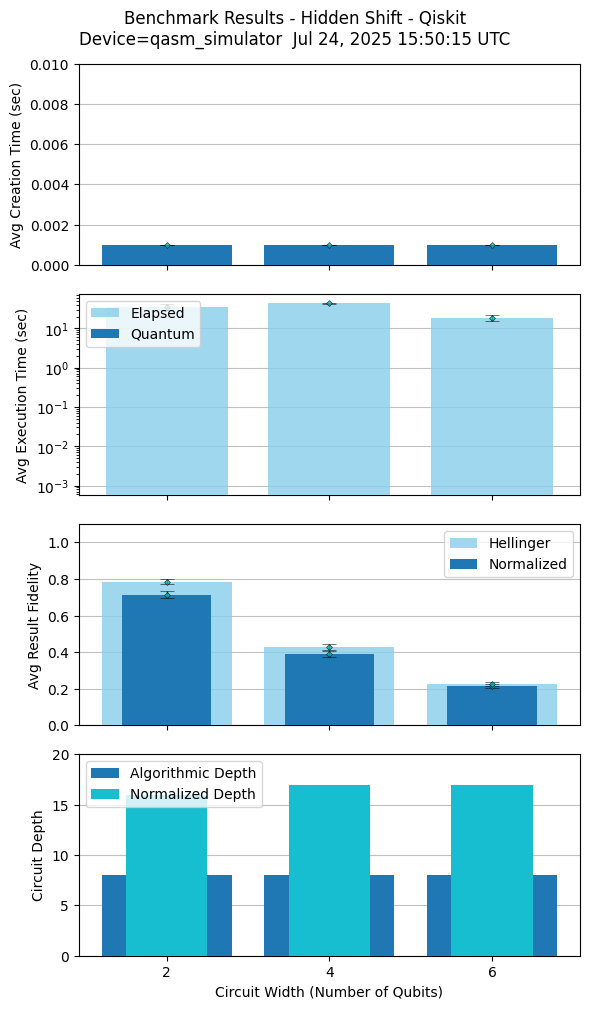

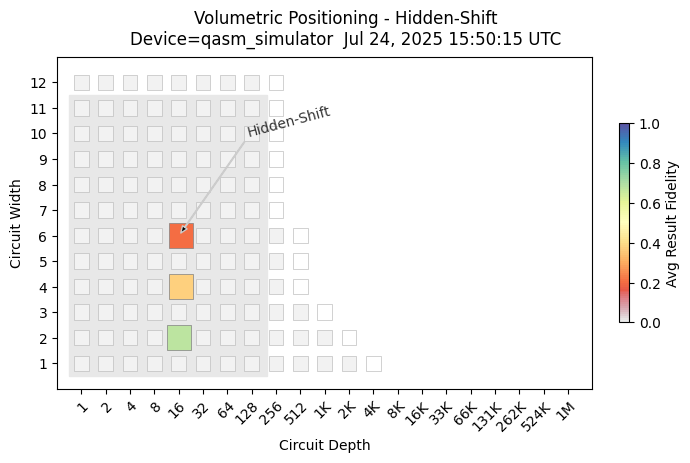

In [43]:
import sys
sys.path.insert(1, "hidden-shift")
import hs_benchmark
hs_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Grover

Grover's Search Benchmark Program - Qiskit
... execution starting at Jul 24, 2025 15:55:23 UTC
************
Executing [4] circuits with num_qubits = 2
************
Executing [6] circuits with num_qubits = 3
************
Executing [6] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 13, 0.112
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 13, 0.122, 2.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.001, 43.894, 0.0 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.658, 0.544

************
Executing [6] circuits with num_qubits = 5
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 24, 0.089
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 50, 0.316, 24.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.001, 57.213, 0.0 secs
Average Hellinger, Normalized Fidelity for the 3 qubit grou

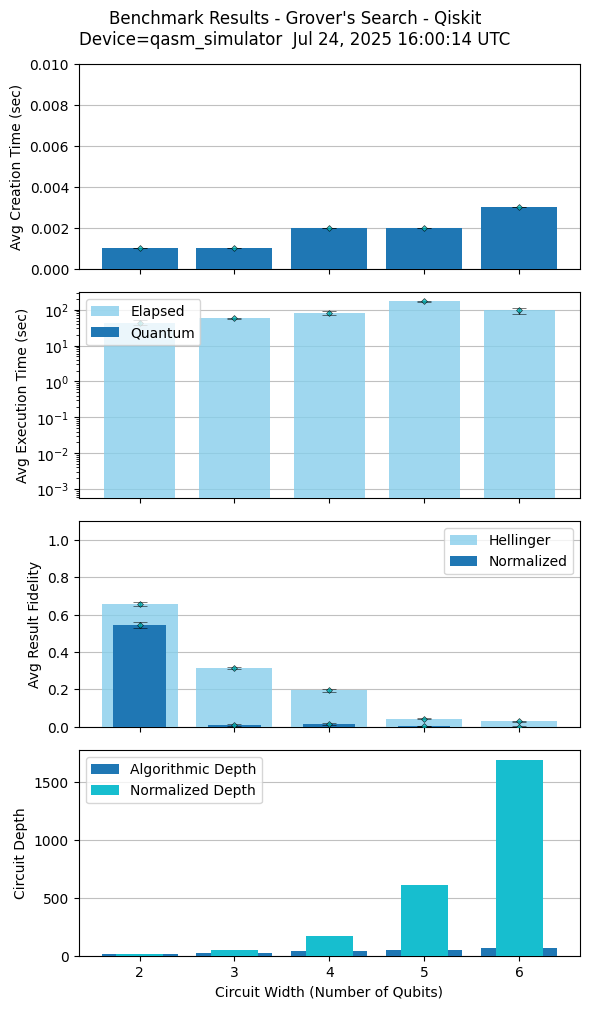

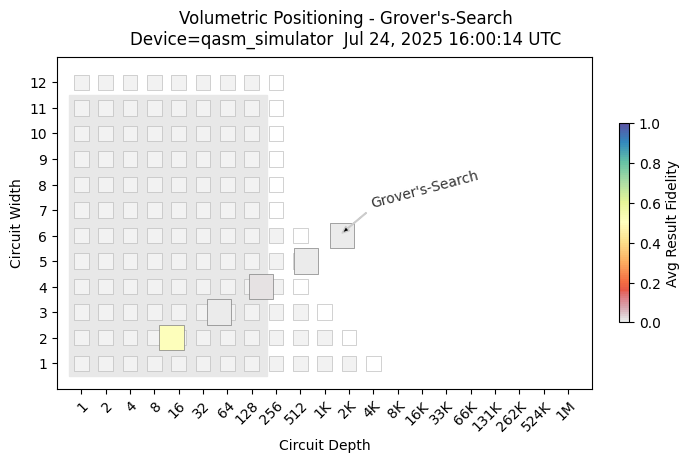

In [46]:
import sys
sys.path.insert(1, "grovers/qiskit")
import grovers_benchmark
grovers_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Phase Estimation

Phase Estimation Benchmark Program - Qiskit
... execution starting at Jul 24, 2025 16:00:15 UTC
************
Executing [4] circuits with num_qubits = 3
************
Executing [6] circuits with num_qubits = 4
************
Executing [6] circuits with num_qubits = 5
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 16, 0.316
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 16, 0.187, 3.75
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.004, 41.501, 0.0 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.601, 0.468

************
Executing [6] circuits with num_qubits = 6
************
Average Circuit Algorithmic Depth, ξ (xi) for the 4 qubit group = 27, 0.353
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 4 qubit group = 28, 0.261, 9.667
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.004, 49.713, 0.0 secs
Average Hellinger, Normalized Fidelity for the 4 qubit g

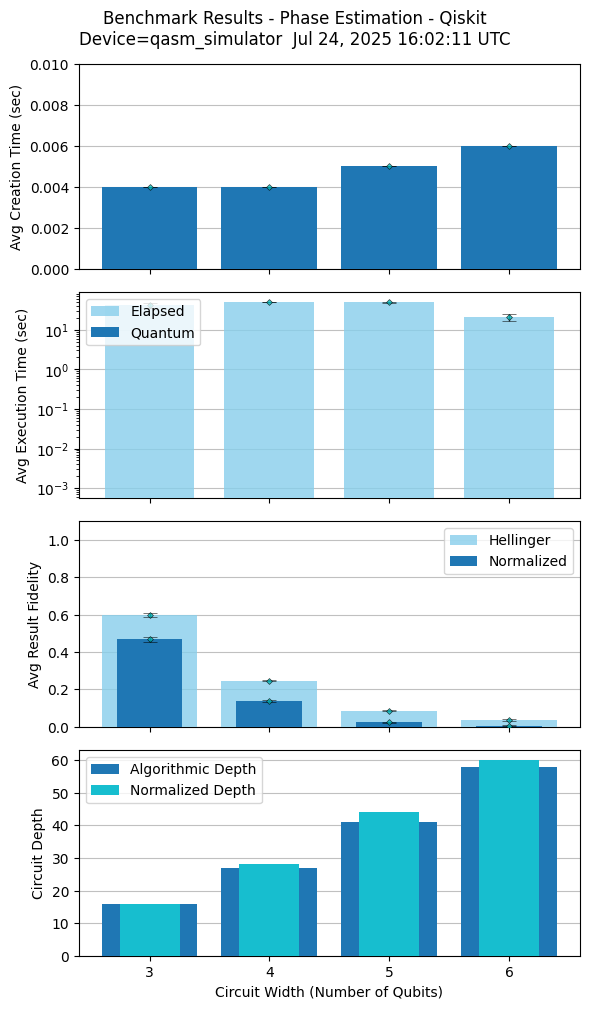

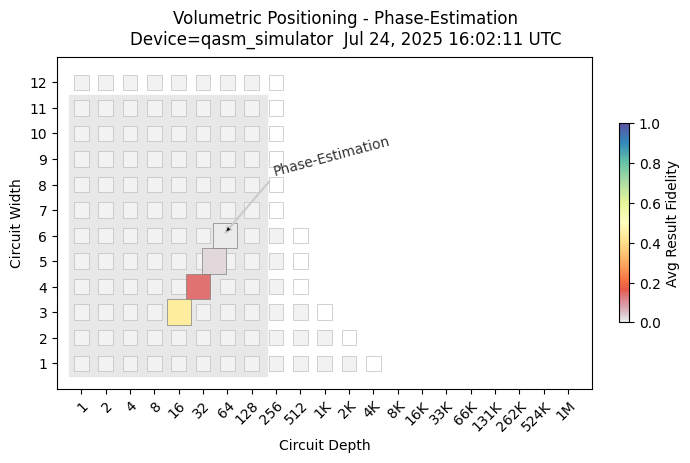

In [47]:
import sys
sys.path.insert(1, "phase-estimation")
import pe_benchmark
pe_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### HHL Linear Solver

In [48]:
import sys
sys.path.insert(1, "hhl/qiskit")
import hhl_benchmark

hhl_benchmark.verbose=False

hhl_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1, use_best_widths=True,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

HHL Benchmark Program - Qiskit
... execution starting at Jul 24, 2025 16:02:12 UTC
************
Executing 6 circuits with 4 qubits, using 1 input qubits and 1 clock qubits
ERROR: Failed to execute circuit 4 1006
... exception = Failed to parse OpenQASM string: 
ERROR: Failed to execute circuit 4 2006
... exception = Failed to parse OpenQASM string: 
ERROR: Failed to execute circuit 4 3006
... exception = Failed to parse OpenQASM string: 
ERROR: Failed to execute circuit 4 4006
... exception = Failed to parse OpenQASM string: 
ERROR: Failed to execute circuit 4 5006
... exception = Failed to parse OpenQASM string: 
ERROR: Failed to execute circuit 4 6006
... exception = Failed to parse OpenQASM string: 
************
Executing 6 circuits with 5 qubits, using 1 input qubits and 2 clock qubits
ERROR: Failed to execute circuit 5 1006
... exception = Failed to parse OpenQASM string: 
ERROR: Failed to execute circuit 5 2006
... exception = Failed to parse OpenQASM string: 
ERROR: Failed to ex

### Amplitude Estimation

In [ ]:
import sys
sys.path.insert(1, "amplitude-estimation/qiskit")


import ae_benchmark
ae_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)



['/home/iszilveszter/work/cuda-quantum/QC-App-Oriented-Benchmarks/_common/qiskit', 'amplitude-estimation/qiskit', '../../_common', '../../_common/qiskit', '../../quantum-fourier-transform/qiskit', '_common', '_common/qiskit', 'quantum-fourier-transform/qiskit', 'amplitude-estimation/qiskit', '../../_common', '../../_common/qiskit', '../../quantum-fourier-transform/qiskit', '_common', '_common/qiskit', 'quantum-fourier-transform/qiskit', 'amplitude-estimation/qiskit', '../../_common', '../../_common/qiskit', '../../quantum-fourier-transform/qiskit', '_common', '_common/qiskit', 'quantum-fourier-transform/qiskit', 'hhl/qiskit', '/home/iszilveszter/work/cuda-quantum/QC-App-Oriented-Benchmarks/_common', '/home/iszilveszter/work/cuda-quantum/QC-App-Oriented-Benchmarks/phase-estimation/qiskit', 'phase-estimation', '../../_common', '../../_common/qiskit', '_common', '_common/qiskit', 'grovers/qiskit', '/home/iszilveszter/work/cuda-quantum/QC-App-Oriented-Benchmarks/quantum-fourier-transform/q

ImportError: cannot import name 'inv_qft_gate' from 'qft_benchmark' (/home/iszilveszter/work/cuda-quantum/QC-App-Oriented-Benchmarks/quantum-fourier-transform/qft_benchmark.py)

### Monte Carlo

In [ ]:
import sys
sys.path.insert(1, "monte-carlo/qiskit")
import mc_benchmark
mc_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Hamiltonian Simulation - Method 1 

In [ ]:
import sys
sys.path.insert(1, "hamiltonian-simulation/qiskit")
import hamiltonian_simulation_benchmark
hamiltonian_simulation_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Hamiltonian Simulation - Method 2 

In [ ]:
import sys
sys.path.insert(1, "hamiltonian-simulation/qiskit")
import hamiltonian_simulation_benchmark
hamiltonian_simulation_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### VQE - Method 1

In [ ]:
import sys
sys.path.insert(1, "vqe/qiskit")
import vqe_benchmark
vqe_num_shots=4098
vqe_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits,
                max_circuits=max_circuits, num_shots=vqe_num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Shor - Method 1

In [ ]:
import sys
sys.path.insert(1, "shors/qiskit")
import shors_benchmark
shors_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=1, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Shor - Method 2

In [ ]:
import sys
sys.path.insert(1, "shors/qiskit")
import shors_benchmark
shors_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, max_circuits=1, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Quantum Fourier Transform - Method 1

Quantum Fourier Transform (1) Benchmark Program - Qiskit
... execution starting at Jul 24, 2025 16:05:37 UTC
************
Executing [4] circuits with num_qubits = 2
************
Executing [6] circuits with num_qubits = 3
************
Executing [6] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 9, 0.224
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 18, 0.211, 4.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.001, 43.452, 0.0 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.803, 0.737

************
Executing [6] circuits with num_qubits = 5
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 15, 0.364
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 35, 0.296, 12.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.001, 54.276, 0.0 secs
Average Hellinger, Normalized Fidelity for the

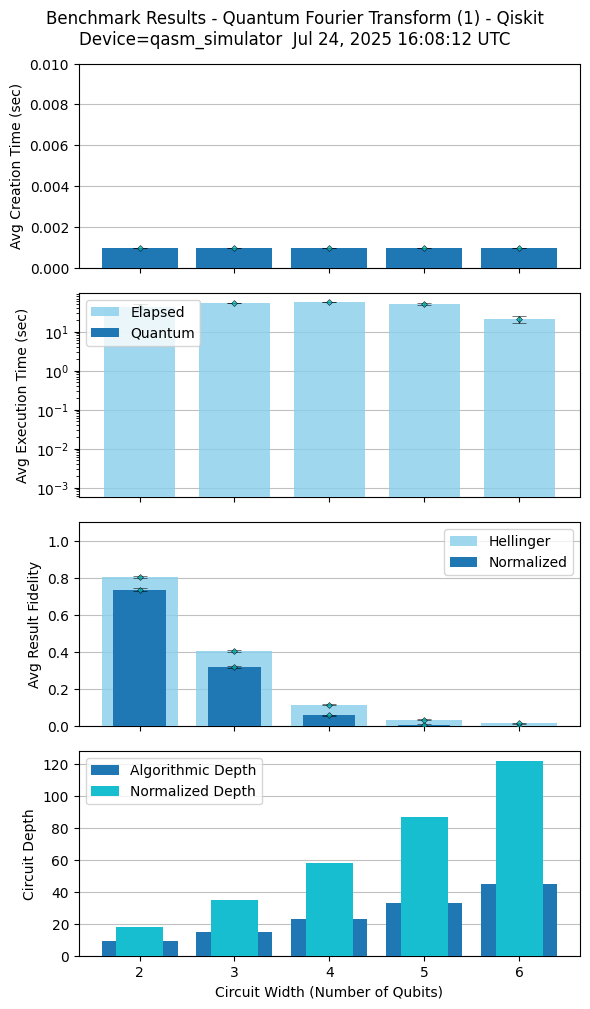

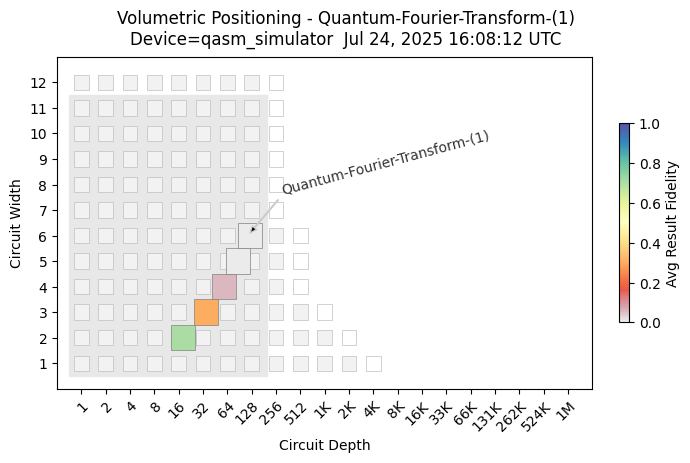

In [53]:
import sys
sys.path.insert(1, "quantum-fourier-transform")
import qft_benchmark
qft_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=1,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Quantum Fourier Transform - Method 2

Quantum Fourier Transform (2) Benchmark Program - Qiskit
... execution starting at Jul 24, 2025 15:52:51 UTC
************
Executing [4] circuits with num_qubits = 2
************
Executing [6] circuits with num_qubits = 3
************
Executing [6] circuits with num_qubits = 4
************
Average Circuit Algorithmic Depth, ξ (xi) for the 2 qubit group = 6, 0.143
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 2 qubit group = 8, 0.268, 2.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0.001, 42.827, 0.0 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.88, 0.839

************
Executing [6] circuits with num_qubits = 5
************
Average Circuit Algorithmic Depth, ξ (xi) for the 3 qubit group = 9, 0.25
Average Normalized Transpiled Depth, ξ (xi), 2q gates for the 3 qubit group = 16, 0.325, 6.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0.001, 53.195, 0.0 secs
Average Hellinger, Normalized Fidelity for the 3 qu

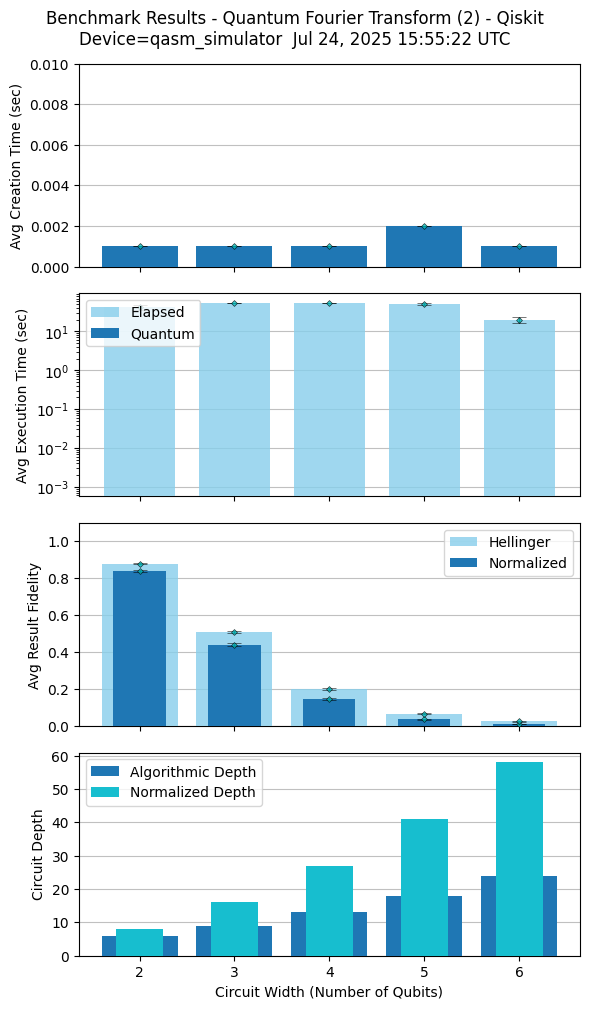

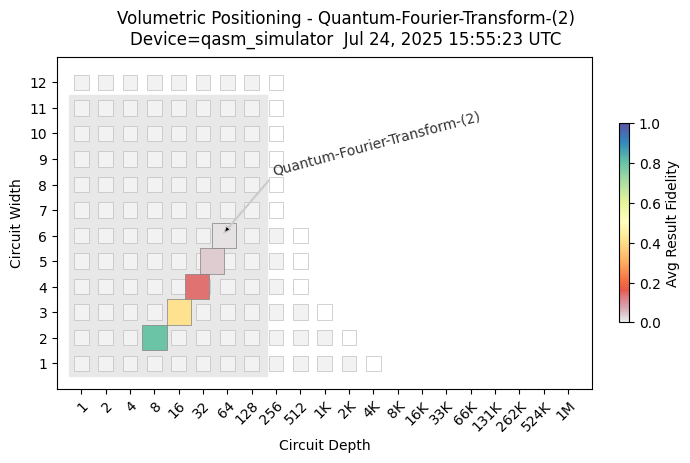

In [ ]:
import sys
sys.path.insert(1, "quantum-fourier-transform")
import qft_benchmark
qft_benchmark.run(min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
                max_circuits=max_circuits, num_shots=num_shots,
                method=2,
                backend_id=backend_id, provider_backend=provider_backend,
                hub=hub, group=group, project=project, exec_options=exec_options)

### Close session
IMPORTANT: This cell is provided as a way to close an active session if for some reason the benchmarks abort abnormally.
If so, execute the close_session function manually to terminate an open session. Normally, this is done automatically.

In [ ]:
import sys
sys.path.insert(1, "_common")
import execute as ex

ex.close_session()

In [ ]:
import sys
sys.path.insert(1, "_common")
import metrics

# metrics.depth_base = 2
# metrics.QV = 0
# apps = [ "Hidden Shift", "Grover's Search", "Quantum Fourier Transform (1)", "Hamiltonian Simulation" ]
# backend_id='qasm_simulator'

metrics.plot_all_app_metrics(backend_id, do_all_plots=False, include_apps=None)